In [46]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import seaborn as sns


data = pd.read_csv('housing.csv')
# log_transformer = FunctionTransformer(np.log1p)


In [47]:
x = data.drop('median_house_value',axis=1)
y = data['median_house_value']

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

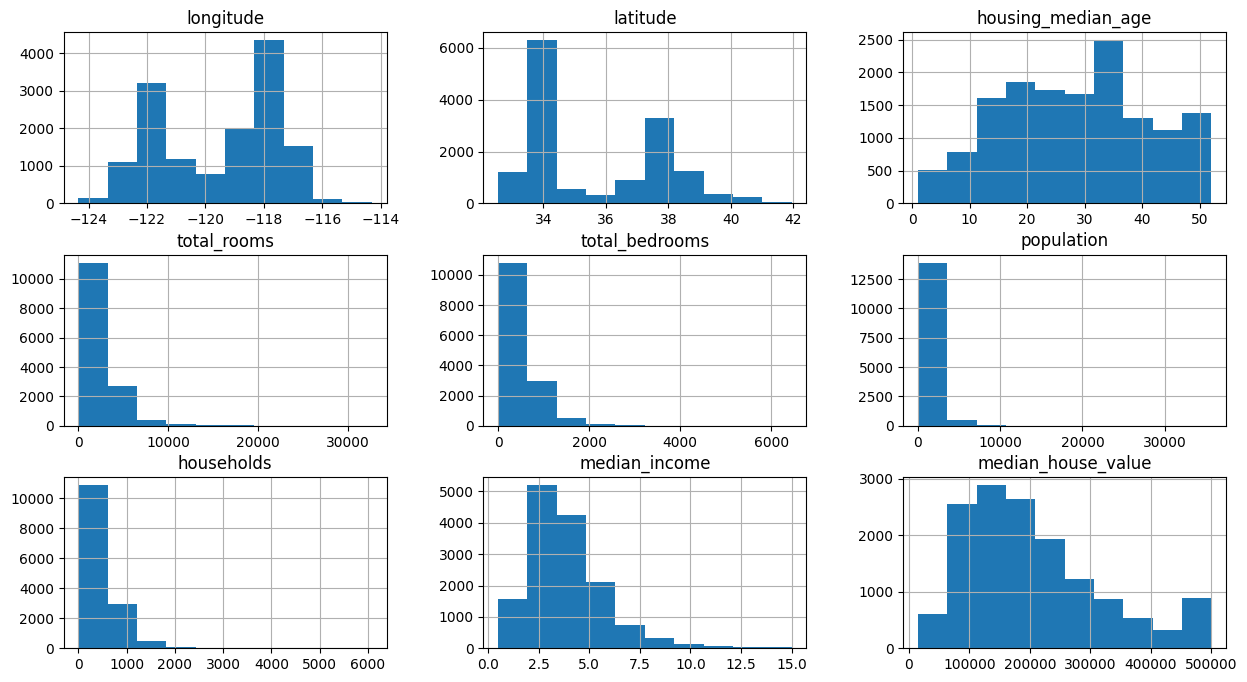

In [48]:
train_data = X_train.join(y_train)
train_data.hist(figsize=(15,8))

In [49]:
skewed_cols = ['total_rooms', 'total_bedrooms', 'population', 'households']
other_cols = ['longitude', 'latitude', 'housing_median_age', 'median_income']

skewed_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='median')),
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])


other_pipeline = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy='median')),
    ("scaler",StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('skewed_pipe', skewed_pipeline,skewed_cols),
        ('basic',other_pipeline,other_cols)
    ]
)


In [50]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
feature_names = skewed_cols + other_cols
X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed, columns=feature_names)
X_test_preprocessed = preprocessor.transform(X_test)

array([[<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>],
       [<Axes: title={'center': 'housing_median_age'}>,
        <Axes: title={'center': 'median_income'}>, <Axes: >]],
      dtype=object)

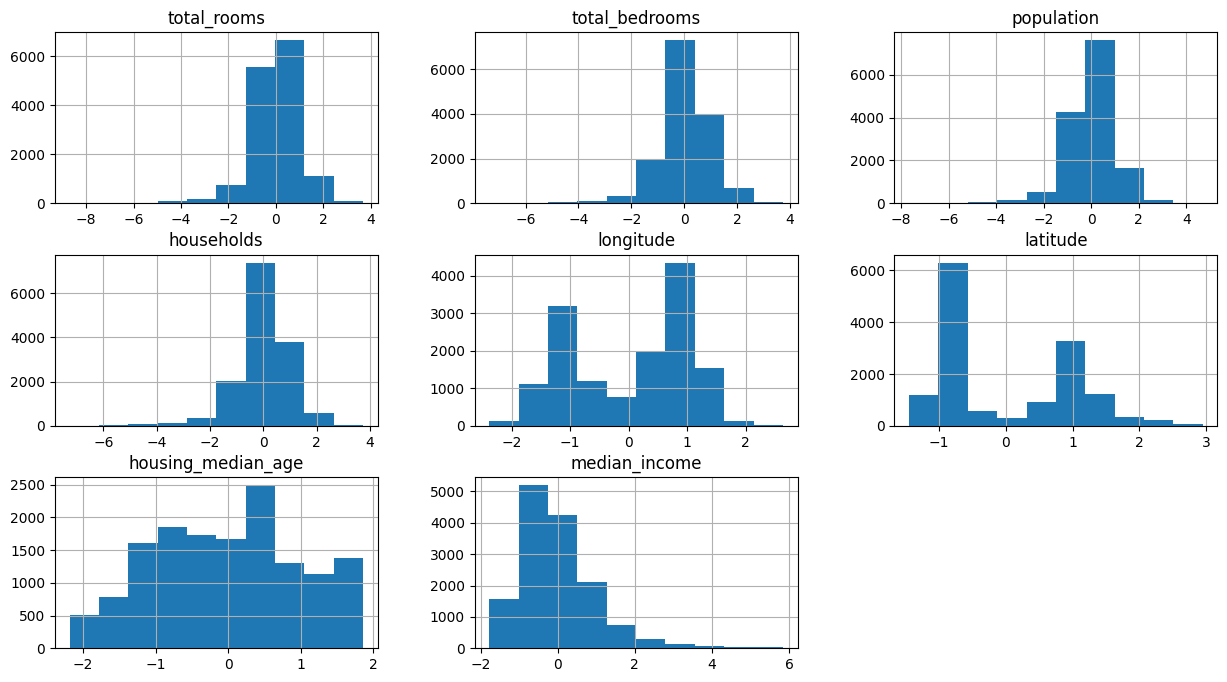

In [51]:
X_train_preprocessed_df.hist(figsize=(15,8))

<Axes: >

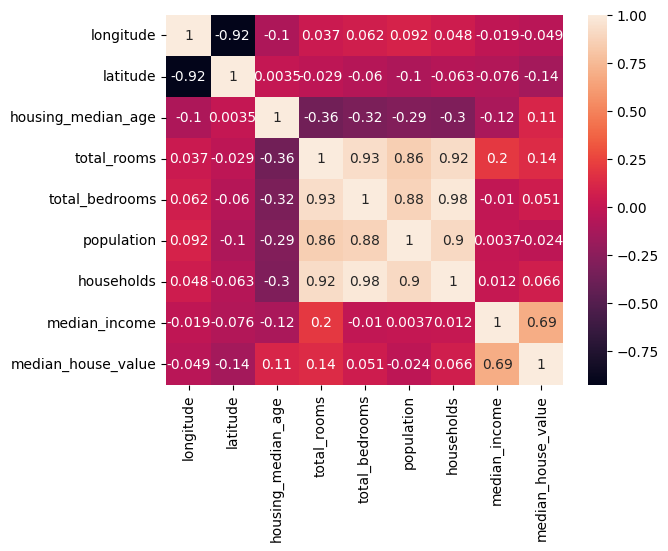

In [52]:
sns.heatmap(train_data.corr(numeric_only=True),annot=True)

In [53]:
lr = LinearRegression()
lr.fit(X_train_preprocessed,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
y_pred_lr = lr.predict(X_test_preprocessed)

In [55]:
mae = mean_absolute_error(y_test,y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2 = r2_score(y_test,y_pred_lr)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}") 



MAE: 49719.624816352254
RMSE: 68667.87145060448
R²: 0.6407518108219643


In [56]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_preprocessed,y_train)

y_pred_rf = rf.predict(X_test_preprocessed)

In [57]:
mae_rf = mean_absolute_error(y_test,y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2_rf = r2_score(y_test,y_pred_rf)

print(f"MAE: {mae_rf}")
print(f"RMSE: {rmse_rf}")
print(f"R²: {r2_rf}") 

MAE: 32518.76624677003
RMSE: 49765.133035997766
R²: 0.8113148351546018


In [58]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid.fit(X_train_preprocessed, y_train)

print("Best Parameters:", grid.best_params_)
best_rf = grid.best_estimator_

y_pred_best_rf = best_rf.predict(X_test_preprocessed)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'max_depth': None, 'n_estimators': 200}


In [59]:
mae_best_rf = mean_absolute_error(y_test,y_pred_best_rf)
rmse_best_rf = np.sqrt(mean_squared_error(y_test,y_pred_best_rf))
r2_best_rf = r2_score(y_test,y_pred_best_rf)

print(f"MAE: {mae_best_rf}")
print(f"RMSE: {rmse_best_rf}")
print(f"R²: {r2_best_rf}") 

MAE: 32451.249348352714
RMSE: 49647.732380378795
R²: 0.8122040373593467


In [60]:
# xgb = XGBRegressor(random_state=42)
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42
)
xgb.fit(X_train_preprocessed,y_train)

y_pred_xgb = xgb.predict(X_test_preprocessed)

In [61]:
mae_xgb = mean_absolute_error(y_test,y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test,y_pred_xgb))
r2_xgb = r2_score(y_test,y_pred_xgb)

print(f"MAE: {mae_xgb}")
print(f"RMSE: {rmse_xgb}")
print(f"R²: {r2_xgb}") 

MAE: 33920.49083621003
RMSE: 49741.255024785045
R²: 0.8114958593104129


In [62]:
y_train_pred = xgb.predict(X_train_preprocessed)
y_test_pred = xgb.predict(X_test_preprocessed)

In [63]:
# TRAIN
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# TEST
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("TRAIN:", train_mae, train_rmse, train_r2)
print("TEST :", test_mae, test_rmse, test_r2)

TRAIN: 31395.38261797156 45154.30896121573 0.8478078868600869
TEST : 33920.49083621003 49741.255024785045 0.8114958593104129
